In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


srcdir = os.path.join(home, "gigalens/src/")
current_dir = os.path.join(home, f"GIGALens-Code/source_modeling/")

['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import jax
from jax import random
import numpy as np
import json
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from alternate_inference.mclmc_alt import MCLMC
tfd = tfp.distributions

In [3]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.light import shapelets

import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
import functools
from typing import List, Dict

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit
from jax import lax
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d
from gigalens.jax.simulator import LensSimulator
import gigalens.model
import gigalens.simulator

In [4]:
# sim_num = "01"
# cam = "12"
# source_plane_dir = os.path.join(current_dir, f"vela_sources/vela{sim_num}_cam{cam}_a0.500_f814w/")
# save_dir = os.path.join(current_dir, f"vela_sim_systems/vela{sim_num}_cam{cam}_a0.500_f814w/")

In [5]:

def load_vela_sim_system(sim_num, cam):
    source_plane_dir = os.path.join(current_dir, f"vela_sources/vela{sim_num}_cam{cam}_a0.500_f814w/")
    save_dir = os.path.join(current_dir, f"vela_sim_systems/vela{sim_num}_cam{cam}_a0.500_f814w/")
    
    psf = np.load(os.path.join(source_plane_dir, "psf.npy"))
    with open(os.path.join(source_plane_dir, "metadata.json")) as f:
        meta = json.load(f)
    
    
    source_img_pixel_scale = meta['source_pixel_scale_arcsec']
    delta_pix = meta['instrument_pixel_scale_arcsec']
    num_pix = 200
    
    sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=1, kernel=psf)
    
    observed_img = jnp.load(os.path.join(save_dir, "lens_img.npy"))
    
    with open(os.path.join(save_dir, "true_params"), 'rb') as file_handle:
        true_params = pickle.load(file_handle)
    

    
    return observed_img, true_params, sim_config

In [6]:
def vela_system_model(sim_config, use_shapelets=True, n_max=10):
    lens_prior = tfd.JointDistributionSequential(
        [
            tfd.JointDistributionNamed(
                dict(
                    theta_E=tfd.LogNormal(jnp.log(1.25), 0.4),
                    gamma= tfd.TruncatedNormal(2, 0.5, 1, 3), #! CHANGE
                    e1=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                    e2=tfd.TruncatedNormal(0, 0.2, -0.5, 0.5),
                    center_x=tfd.Normal(0, 0.06),
                    center_y=tfd.Normal(0, 0.06),
                )
            ),
            tfd.JointDistributionNamed(
                dict(gamma1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5), gamma2=tfd.Normal(0, 0.1, -0.5, 0.5))
            ),
        ]
    )
    lens_light_prior = tfd.JointDistributionSequential(
        [
            tfd.JointDistributionNamed(
                dict(
                    R_sersic=tfd.LogNormal(jnp.log(1.6), 0.25),
                    n_sersic=tfd.Uniform(0.5, 8),
                    e1=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                    e2=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                    center_x=tfd.Normal(0, 0.02),
                    center_y=tfd.Normal(0, 0.02),
                    # Ie=tfd.LogNormal(jnp.log(300.0), 0.5),
                )
            )
        ]
    )
    
    
    # amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}
    

    if use_shapelets:
        source_light_prior = tfd.JointDistributionSequential(
            [
                tfd.JointDistributionNamed(
                    dict(
                        beta=tfd.LogNormal(jnp.log(0.7), 0.4),
                        center_x=tfd.Normal(0, 0.5),
                        center_y=tfd.Normal(0, 0.5),
                        # **amp_prior
                    )
                ),
            ]
        )
    else:
        lens_light_prior = tfd.JointDistributionSequential(
            [
                tfd.JointDistributionNamed(
                    dict(
                        R_sersic=tfd.LogNormal(jnp.log(1.6), 0.4),
                        n_sersic=tfd.Uniform(0.5, 8),
                        e1=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                        e2=tfd.TruncatedNormal(0, 0.1, -0.2, 0.2),
                        center_x=tfd.Normal(0, 0.5),
                        center_y=tfd.Normal(0, 0.5),
                    )
                )
            ]
        )
    
    
    prior = tfd.JointDistributionSequential(
        [lens_prior, lens_light_prior, source_light_prior]
    )
    
    # n_max = 10
    src_model = shapelets.ShapeletsFast(n_max=n_max, use_lstsq=True, interpolate=False) if shapelets else sersic.SersicEllipse(use_lstsq=True)
    phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True)], [src_model])
    lens_sim = LensSimulator(phys_model, sim_config, bs=1)
        
    prob_model = BackwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
    model_seq = ModellingSequence(phys_model, prob_model, sim_config)

    return model_seq, lens_sim

def fixed_prior(profile_params):
    prior_dists = {}
    for key in profile_params:
        val = jnp.squeeze(profile_params[key])
        if len(val.shape) != 0:
            raise ValueError(f'Must have single parameter as truth (leaf shape is {profile_params[key].shape})')
        prior_dists[key] = tfd.Uniform(val-1e-6, val+1e-6)
    return tfd.JointDistributionNamed(prior_dists)

def free_source_fixed_lens_model(sim_config, fixed_params, use_shapelets=True, n_max=10):
    lens_prior = tfd.JointDistributionSequential(
        [fixed_prior(mass_prof_params) for mass_prof_params in fixed_params[0]]
    )
    
    ie_less = fixed_params[1][0].copy()
    del ie_less["Ie"]
    
    
    lens_light_prior = tfd.JointDistributionSequential(
        [
            fixed_prior(ie_less)
        ]
    )
        
    
    source_light_prior = tfd.JointDistributionSequential(
        [
            tfd.JointDistributionNamed(
                dict(
                    beta=tfd.LogNormal(jnp.log(0.7), 0.4),
                    center_x=tfd.Normal(0, 0.01),
                    center_y=tfd.Normal(0, 0.01),
                    # **amp_prior
                )
            ),
        ]
    )
    
    
    prior_fixed_lens = tfd.JointDistributionSequential(
        [lens_prior, lens_light_prior, source_light_prior]
    )

    src_model = shapelets.ShapeletsFast(n_max=n_max, use_lstsq=True, interpolate=False) if shapelets else sersic.SersicEllipse(use_lstsq=True)
    phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True)], [src_model])
    lens_sim = LensSimulator(phys_model, sim_config, bs=1)
        
    prob_model_fixed_lens = BackwardProbModel(prior_fixed_lens, observed_img, background_rms=background_rms, exp_time=exp_time)
    model_seq_fixed_lens = ModellingSequence(phys_model, prob_model_fixed_lens, sim_config)


    return model_seq_fixed_lens, lens_sim

In [7]:
def plot_diagnostics(debug_hist, num_burnin_steps, frac_tune1, frac_tune2, frac_tune3, save_dir):
    stage1 = int(frac_tune1*num_burnin_steps)
    stage2 = int((frac_tune1+frac_tune2)*num_burnin_steps)
    stage3 = int((frac_tune1+frac_tune2+frac_tune3)*num_burnin_steps)
    
    fig, axs = plt.subplots(5, 1, sharex=True)
    ax1, ax2, ax3, ax4, ax_last =axs
    fig.set_size_inches(10, 8)
    ax1.plot(debug_hist.step_size.T)
    ax1.set_title("Chain-Wise Step Size")
    ax1.set_ylabel("Step Size")
    # ax1.set_ylim(top=10)
    # ax1.set_yscale('log')
    
    ax2.plot(debug_hist.L.T)
    ax2.set_title("Chain-Wise L")
    ax2.set_ylabel("L")
    # ax2.set_ylim(top=20)
    
    
    
    inverse_mass_matrix_hist = debug_hist.inverse_mass_matrix[0]
    vmapped_eigval = jax.vmap(lambda x: jnp.linalg.eig(x)[0])
    mass_mat_eigval = vmapped_eigval(inverse_mass_matrix_hist)
    min_eigval = jnp.min(mass_mat_eigval, axis=1)
    max_eigval = jnp.max(mass_mat_eigval, axis=1)
    mean_eigval = jnp.mean(mass_mat_eigval, axis=1)
    
    ax3.plot(min_eigval, label='Min', color='blue')
    ax3.plot(max_eigval, label='Max', color='red')
    ax3.plot(mean_eigval, label='Mean', color='black')
    ax3.legend()
    ax3.set_title("Covariance Eigenvalues")
    ax3.set_yscale('log')
    ax3.set_ylabel("Eigenvalue")
    
    
    
    smooth_kernel_size = 30
    kernel = np.ones(smooth_kernel_size) / smooth_kernel_size
    xi_chain = debug_hist.xi[8]
    xi_smoothed = np.convolve(xi_chain, kernel, mode='same')
    ax4.plot(xi_chain, alpha=0.5, color='blue')
    ax4.plot(xi_smoothed, alpha=1.0, color='blue')
    ax4.set_yscale('log')
    ax4.set_ylabel("xi for chain 0")
    ax4.axhline(1.0, color='black', linestyle='--')
    
    ax_last.set_xlabel("Step")
    
    ax_last.set_title("Nans?")
    ax_last.imshow(debug_hist.nonan[:,:stage2], aspect='auto', interpolation='none', cmap='RdYlGn')
    
    for ax in axs:
        ax.axvline(stage1, color='red', linestyle='--')
        ax.axvline(stage2, color='blue', linestyle='--')
        ax.axvline(stage3, color='green', linestyle='--')
    
    
    plt.savefig(os.path.join(save_dir, "mclmc_diagnostics.png"))
    plt.close(fig)

In [8]:
def cornerplot_all(mclmc_samples, qz, prob_model, save_dir):
    dim=mclmc_samples.shape[-1]
    run_key = jax.random.key(0)
    samples = mclmc_samples[:, :,:].reshape(-1, dim) #samples_mclmc 
    MCMC_x = prob_model.bij.forward(list(samples.T))
    
    # adapt_cov = debug_hist.inverse_mass_matrix[0, -1]
    # adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
    # adapt_qz_samples = adapt_qz.sample((10000,), run_key)
    # adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))
    
    SVI_samples = qz.sample((1000,), run_key)
    SVI_x = prob_model.bij.forward(list(SVI_samples.T))
    
    # MAP_x = prob_model.bij.forward(list(best.T))
    
    plot_params = cornerplot_labels(MCMC_x)#[:14]
    
    # hmc_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, dim).T))
    
    # n_samp = hmc_samples.shape[0]*hmc_samples.shape[1]
    # rand_idx = np.random.choice(np.arange(n_samp), size=(10000,), replace=True)
    
    
    
    n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
    rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
    fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='black',plot_params=plot_params, truth=true_params_shp)
    
    
    # cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], hmc_x), color='green',plot_params=plot_params, fig=fig)
    
    cornerplot_posterior(SVI_x, fig=fig, color='blue', plot_params=plot_params)
    # cornerplot_posterior(adapt_qz_x, fig=fig, color='purple', plot_params=plot_params)#,overplots=MAP_x)
    
    plt.savefig(os.path.join(save_dir, "cornerplot.png"))
    plt.close(fig)

In [9]:
import alternate_inference.mclmc_alt
importlib.reload(alternate_inference.mclmc_alt)
from alternate_inference.mclmc_alt import MCLMC_JIT
n_max=10

background_rms = 0.002
exp_time = 2000

# sim_num = "01"
cam = "12"

sim_nums = ["01", "03", "04", "07", "08", "10", "15", "21", "22", "23", "25", "26"]

for sim_num in sim_nums:
    print(f"--------------------------- {sim_num} ---------------------------------")
    save_dir = os.path.join(current_dir, f"vela_sim_systems/vela{sim_num}_cam{cam}_a0.500_f814w/")
    observed_img, true_params, sim_config = load_vela_sim_system(sim_num, cam)  
    
    #* Get truth to start it (to make MAP less intensive)
    model_seq_fixed_lens, lens_sim_fixed_lens = free_source_fixed_lens_model(sim_config, true_params, use_shapelets=True, n_max=n_max)
    model_seq, lens_sim = vela_system_model(sim_config, use_shapelets=True, n_max=n_max)
    prob_model = model_seq.prob_model

    
    pipelinecfg = PipelineConfig(steps=["MAP"],map_kwargs={"num_steps":200, "n_samples":100},)
    results_fixed_lens = run_pipeline(model_seq_fixed_lens, pipelinecfg)

    shp_true = results_fixed_lens["MAP"].MAP_best[2][0]

    lens_light_no_Ie = true_params[1][0].copy()
    del lens_light_no_Ie["Ie"]
    
    
    true_params_shp = [true_params[0], [lens_light_no_Ie], [shp_true]]
    true_z = jnp.stack(prob_model.bij.inverse(true_params_shp)).T
    
    
    fig, axs = plt.subplots(1,4)
    fig.set_size_inches(20,5)
    
    plot_image_results(fig, axs, jnp.array(observed_img), prefix="True Param", lens_sim=lens_sim, predicted_params=true_params_shp, background_rms = background_rms, exp_time = exp_time, use_backward=True, )
    plt.savefig(os.path.join(save_dir, "mass_truth_free_source.png"))
    plt.clf()

    #~~~ Start MCLMC from truth
    best = true_z
    default_start = jnp.diag(jnp.ones((best.shape[-1],))) * 1e-3
    no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(best), scale_tril=default_start)
    qz = no_SVI_qz
    
    num_burnin_steps = 2000
    num_results=2000
    frac_tune1=0.2 #* initial step size tuning
    frac_tune2=0.6 #* Used for mass matrix adaptation
    frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate
    
    debug_hist = MCLMC_JIT(
        model_seq, qz, 
        n_hmc=8, num_burnin_steps=num_burnin_steps, num_results=num_results, 
        desired_energy_variance=5e-3, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
        seed=0, debug_output=True, step_size_adapt_use_psmile=False, use_shard_map=True,progress_bar=True,
    )
    mclmc_samples = debug_hist.position[:, -num_results:, :] # Prev: 75 seconds, then 59 after linear solve improvement, then 45 after
    

    plot_diagnostics(debug_hist, num_burnin_steps, frac_tune1, frac_tune2, frac_tune3, save_dir)

    print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)))
    print(blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1))
    cornerplot_all(mclmc_samples, qz, prob_model, save_dir)

    med_x = prob_model.bij.forward(list(jnp.median(mclmc_samples, axis=(0,1)).T))
    sigma_low = prob_model.bij.forward(list(jnp.quantile(mclmc_samples, q=0.159, axis=(0,1)).T))
    sigma_up = prob_model.bij.forward(list(jnp.quantile(mclmc_samples, q=1-0.159, axis=(0,1)).T))
    def stdev_calc(x, med, sig_low, sig_up):
        above = x > med
        std = (above * (sig_up-med)) + (~above * (med-sig_low))
        return (x-med)/std
    sigma = jax.tree.map(stdev_calc, true_params_shp, med_x, sigma_low, sigma_up)
    print("label : predicted | true | z-score")
    a = jax.tree.map(lambda x, y, z : f"{float(jnp.squeeze(x)):.4f} | {float(jnp.squeeze(y)):.4f} | {float(jnp.squeeze(z)):.4f}", med_x[0], true_params[0], sigma[0])
    print(a)

    jnp.save(os.path.join(save_dir, "mclmc_samples"), mclmc_samples)

--------------------------- 01 ---------------------------------
Starting MAP


Chi-squared: 1.175: 100%|██████████| 200/200 [01:18<00:00,  2.56it/s]


Final Chi-squared: 1.17498


Sampling took 96.66793388826773 s


/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


...

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

In [12]:
# #* Using shapelets fit to unlensed source
# shp_true = {'center_y': jnp.array([-0.1304164]),
#    'center_x': jnp.array([-0.0065171]),
#    'beta': jnp.array([0.1815874])}

# shapelets_coeffs_unlensed = jnp.load(os.path.join(save_dir, "shapelets_nmax10_coeffs.npy"))

# amp_names = shapelets.Shapelets(n_max)._amp_names

# if len(amp_names) != len(shapelets_coeffs_unlensed):
#     raise ValueError("Messed up keeping track of coefficients")

# amp_dict = dict(zip(amp_names, shp_coeffs_unlensed))
# shapelets_with_coeffs = true_params[2][0] | shp_true | amp_dict
# true_unlensed_fit = [true_params[0], true_params[1], [shapelets_with_coeffs]]
# true_unlensed_fit = jax.tree.map(lambda x : x[jnp.newaxis], true_unlensed_fit) 

# phys_model_fwd = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=True)])
# lens_sim_fwd = LensSimulator(phys_model_fwd, sim_config, bs=1)


# fig, axs = plt.subplots(1,4)
# fig.set_size_inches(20,5)

# plot_image_results(fig, axs, jnp.array(observed_img), prefix="True Param", lens_sim=lens_sim, predicted_params=true_unlensed_fit, background_rms = background_rms, exp_time = exp_time, use_backward=True, )
# plt.show()

In [13]:
pipelinecfg = PipelineConfig(steps=["MAP"],map_kwargs={"num_steps":350, "n_samples":500}, )
results = run_pipeline(model_seq, pipelinecfg)

Starting MAP


  0%|          | 0/350 [00:16<?, ?it/s]

KeyboardInterrupt: 

In [11]:
# qz = results["SVI"].qz
# best = results["MAP"].best_z

# jnp.save(os.path.join(save_dir, "best.npy"), best)
# jnp.savez(os.path.join(save_dir, 'qz.npz'), loc=qz.loc, scale_tril=qz.scale_tril)
# 

# best = jnp.load(os.path.join(save_dir, "best.npy"))
best = true_z#jnp.load(os.path.join(save_dir, "best.npy"))


# f = jnp.load(os.path.join(save_dir, 'qz.npz'))
# qz = tfd.MultivariateNormalTriL(loc=f['loc'], scale_tril=f['scale_tril'])

default_start = jnp.diag(jnp.ones((best.shape[-1],))) * 1e-3
no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(best), scale_tril=default_start)
qz = no_SVI_qz
# results_halo["SVI"].qz = no_SVI_qz

# qz_halo = results_halo["SVI"].qz

In [12]:
import alternate_inference.mclmc_alt
importlib.reload(alternate_inference.mclmc_alt)
from alternate_inference.mclmc_alt import MCLMC_JIT, isokinetic_velocity_verlet_smart

num_burnin_steps = 2000
num_results=2000
frac_tune1=0.2 #* initial step size tuning
frac_tune2=0.6 #* Used for mass matrix adaptation
frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate

debug_hist = MCLMC_JIT(
    model_seq, qz, 
    n_hmc=8, num_burnin_steps=num_burnin_steps, num_results=num_results, 
    desired_energy_variance=5e-3, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
    seed=0, debug_output=True, step_size_adapt_use_psmile=False, use_shard_map=True,progress_bar=True,
    # integrator=isokinetic_velocity_verlet_smart
)
mclmc_samples = debug_hist.position[:, -num_results:, :] # Prev: 75 seconds, then 59 after linear solve improvement, then 45 after

Sampling took 96.8081082617864 s


In [13]:
# mclmc_samples = debug_hist.position[:, -num_results:, :]

# jnp.save(os.path.join(save_dir, "mclmc_samples_n13"), mclmc_samples)
# mclmc_samples = jnp.load(os.path.join(save_dir, "mclmc_samples.npy"))

In [15]:
# dim=mclmc_samples.shape[-1]
# samples = mclmc_samples[:, :,:].reshape(-1, dim)
# qz_true =tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=jnp.cov(samples.T))
# hmc_smp = model_seq.HMC(qz_true, n_hmc=8,num_burnin_steps=250, num_results=1000)


In [16]:
# hmc_samples = hmc_smp.transpose((1, 2, 0, 3)).reshape((8, 1000, 17))
# print(jnp.max(blackjax.diagnostics.potential_scale_reduction(hmc_samples, chain_axis=0, sample_axis=1)))
# print(blackjax.diagnostics.effective_sample_size(hmc_samples, chain_axis=0, sample_axis=1))

1.0066067
[1090.4491   996.42993  725.1035   901.62897  914.29193 1196.8162
 1028.096    723.825   1016.3263  1085.0863   965.19055 1043.7175
  905.0965  1047.2188  1710.9678  1428.4531  1067.5458 ]


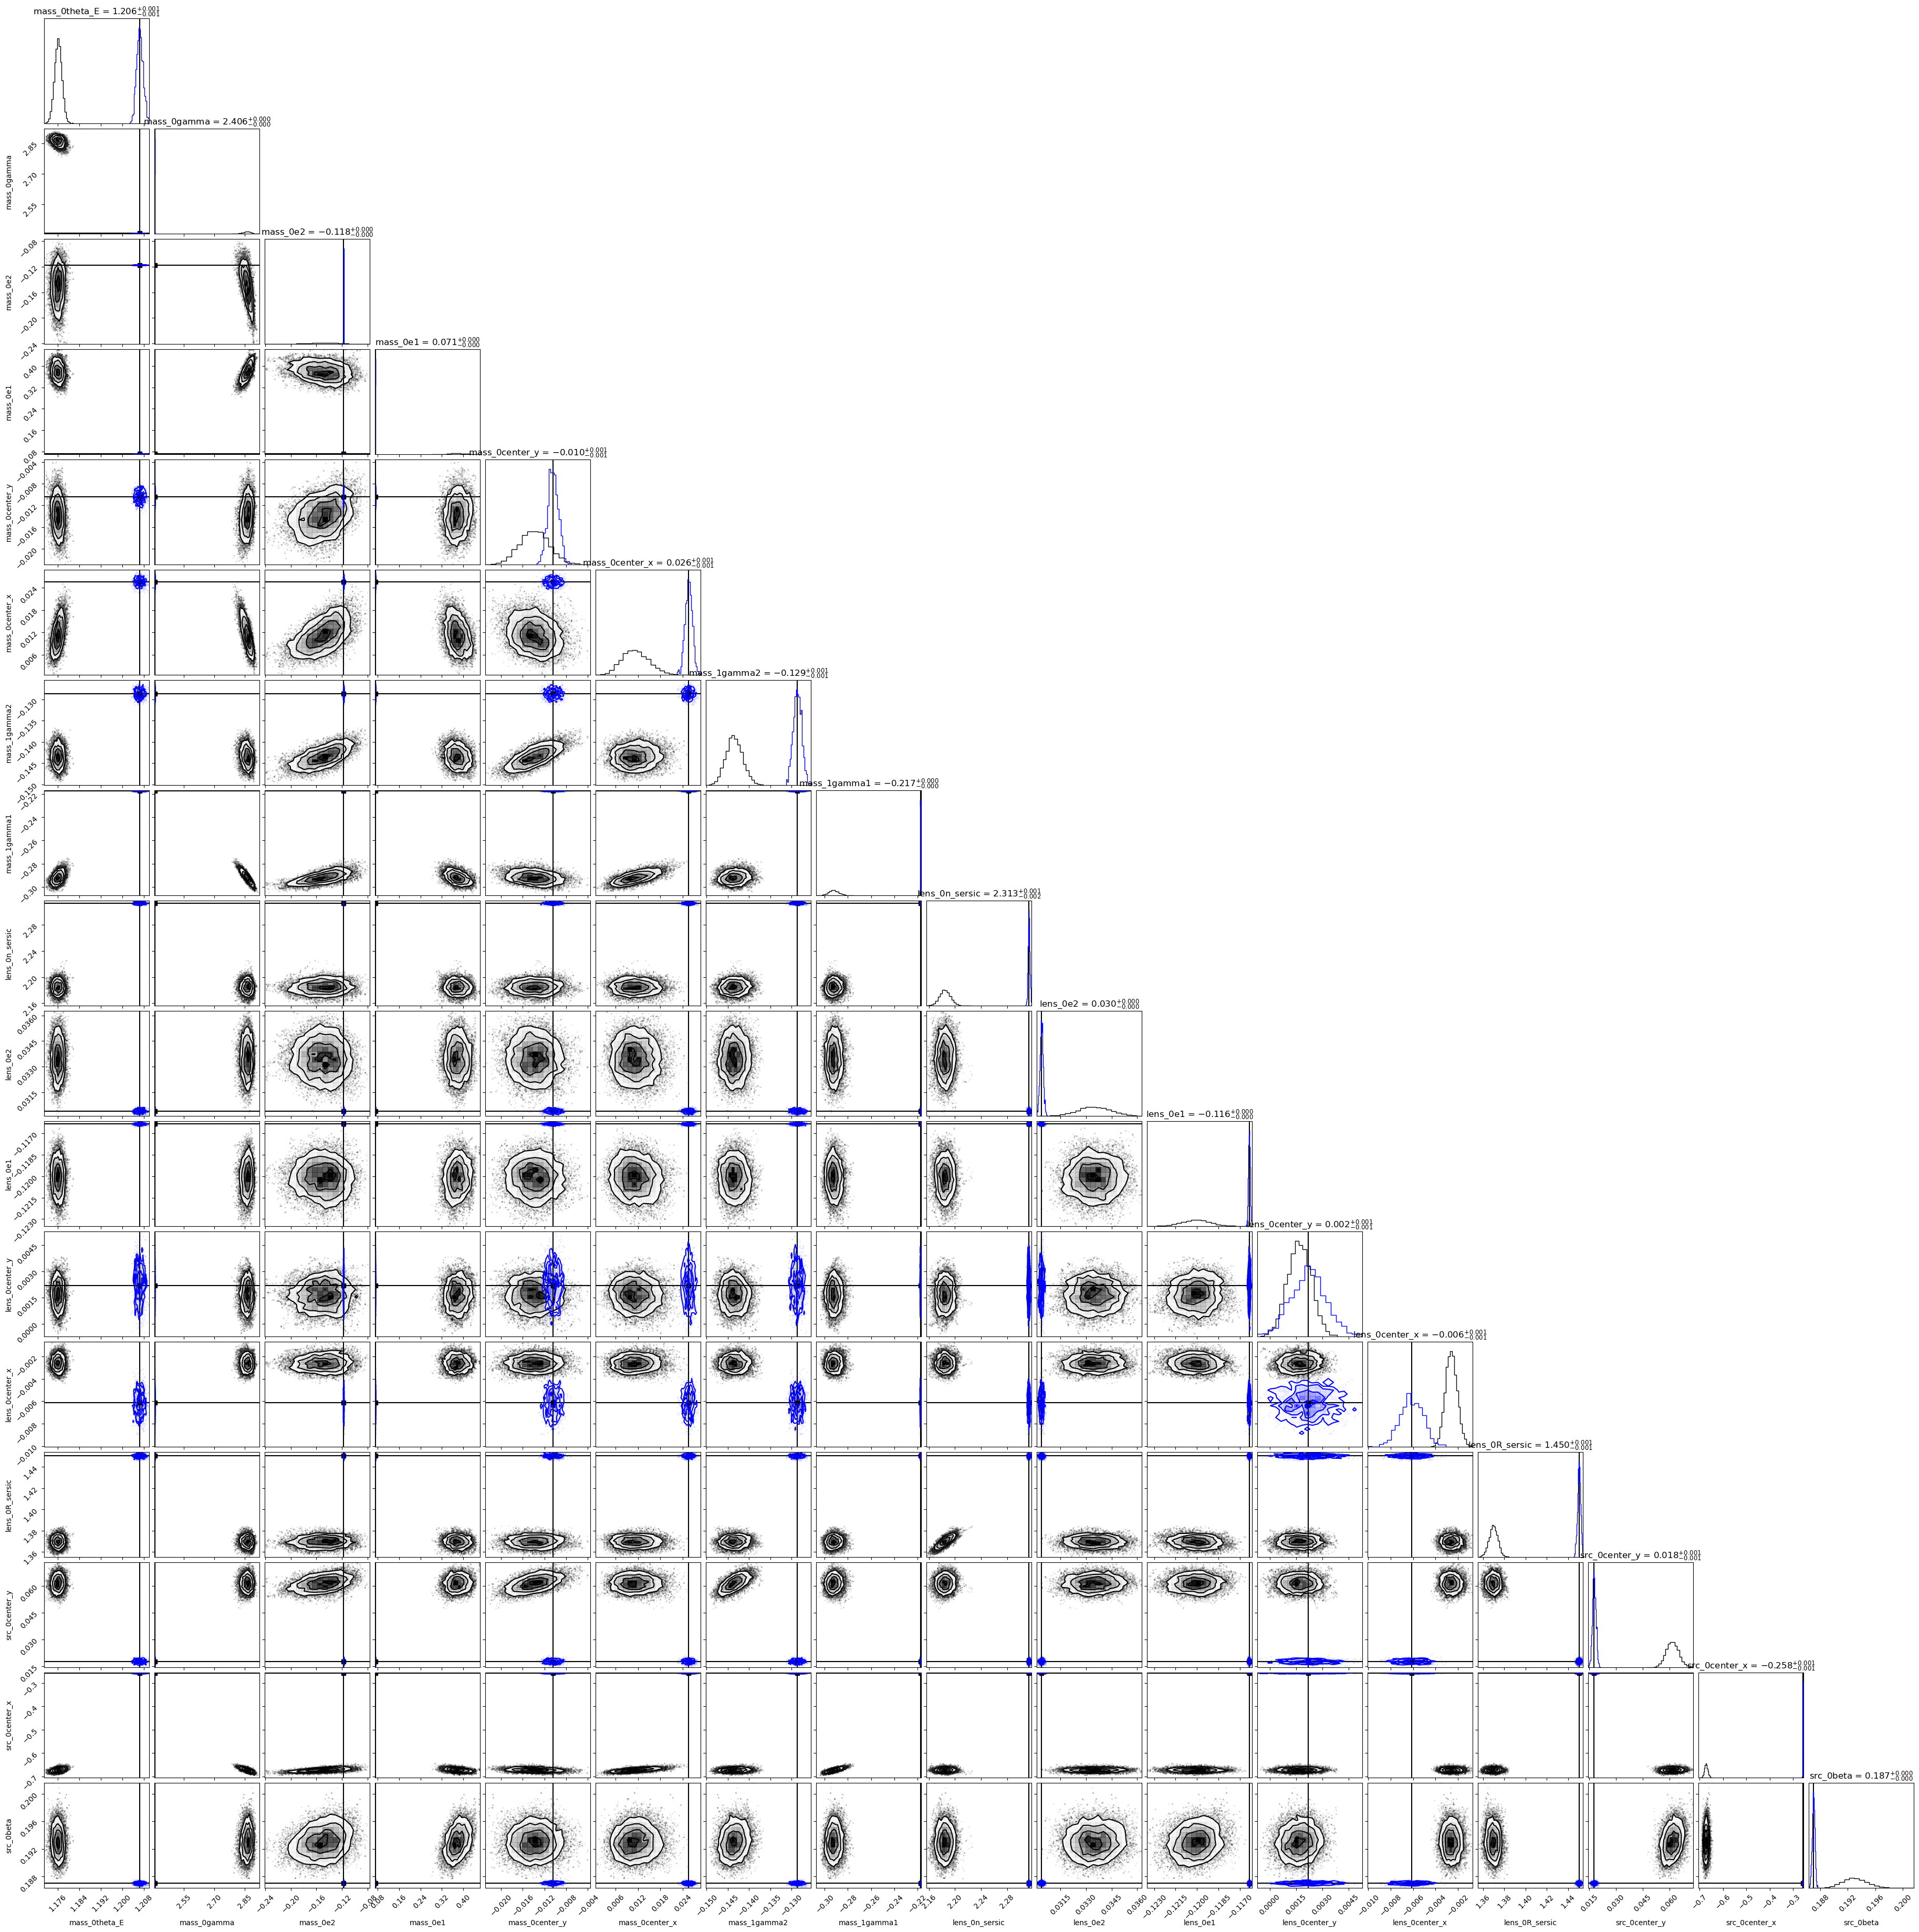

In [17]:
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)))
print(blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1))
dim=mclmc_samples.shape[-1]
run_key = jax.random.key(0)
samples = mclmc_samples[:, :,:].reshape(-1, dim) #samples_mclmc 
MCMC_x = prob_model.bij.forward(list(samples.T))

adapt_cov = debug_hist.inverse_mass_matrix[0, -1]
adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
adapt_qz_samples = adapt_qz.sample((10000,), run_key)
adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))

SVI_samples = qz.sample((1000,), run_key)
SVI_x = prob_model.bij.forward(list(SVI_samples.T))

# MAP_x = prob_model.bij.forward(list(best.T))

plot_params = cornerplot_labels(MCMC_x)#[:14]

# hmc_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, dim).T))

# n_samp = hmc_samples.shape[0]*hmc_samples.shape[1]
# rand_idx = np.random.choice(np.arange(n_samp), size=(10000,), replace=True)



n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='black',plot_params=plot_params, truth=true_params_shp)


# cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], hmc_x), color='green',plot_params=plot_params, fig=fig)

cornerplot_posterior(SVI_x, fig=fig, color='blue', plot_params=plot_params)
# cornerplot_posterior(adapt_qz_x, fig=fig, color='purple', plot_params=plot_params)#,overplots=MAP_x)

plt.show()

In [18]:
med_x = prob_model.bij.forward(list(jnp.median(mclmc_samples, axis=(0,1)).T))
sigma_low = prob_model.bij.forward(list(jnp.quantile(mclmc_samples, q=0.159, axis=(0,1)).T))
sigma_up = prob_model.bij.forward(list(jnp.quantile(mclmc_samples, q=1-0.159, axis=(0,1)).T))
def stdev_calc(x, med, sig_low, sig_up):
    above = x > med
    std = (above * (sig_up-med)) + (~above * (med-sig_low))
    return (x-med)/std
sigma = jax.tree.map(stdev_calc, true_params_shp, med_x, sigma_low, sigma_up)
print("label : predicted | true | z-score")
a = jax.tree.map(lambda x, y, z : f"{float(jnp.squeeze(x)):.4f} | {float(jnp.squeeze(y)):.4f} | {float(jnp.squeeze(z)):.4f}", med_x[0], true_params[0], sigma[0])
a

label : predicted | true | z-score


[{'center_x': '0.0111 | 0.0255 | 3.7520',
  'center_y': '-0.0138 | -0.0104 | 1.2656',
  'e1': '0.3775 | 0.0710 | -11.8650',
  'e2': '-0.1493 | -0.1176 | 1.3439',
  'gamma': '2.8625 | 2.4061 | -23.5204',
  'theta_E': '1.1762 | 1.2064 | 22.0666'},
 {'gamma1': '-0.2923 | -0.2173 | 17.0221',
  'gamma2': '-0.1435 | -0.1286 | 7.3069'}]

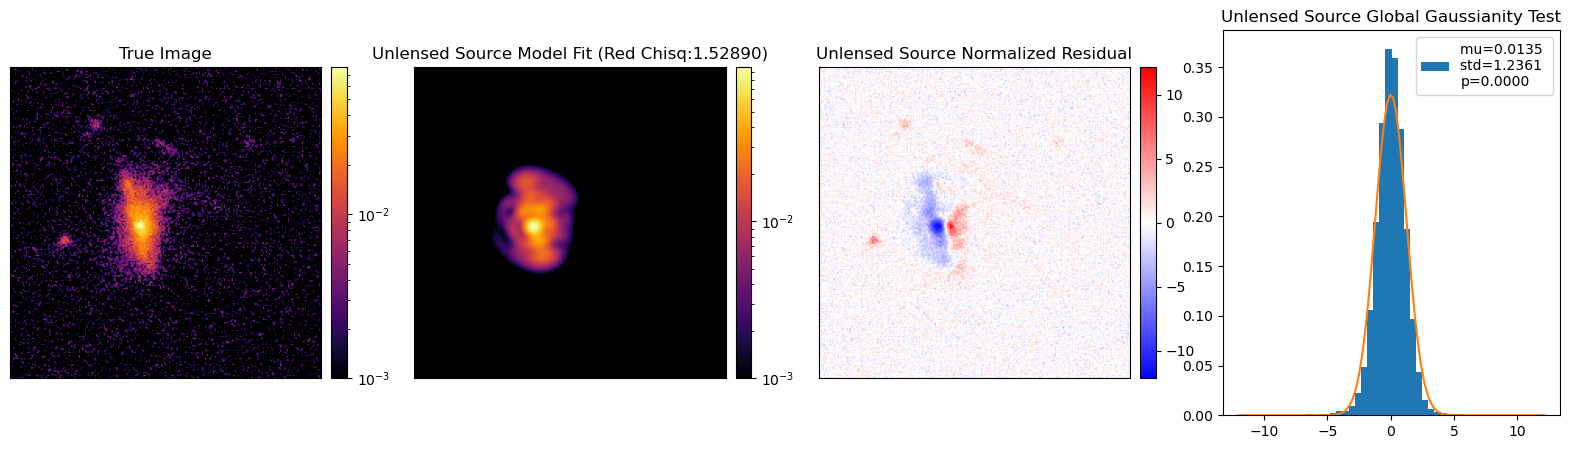

In [19]:
class NoLens(gigalens.profile.MassProfile):
    _name = "NoLens"
    _params = ["a"]

    def __init__(self):
        super().__init__()

    @functools.partial(jit, static_argnums=(0,))
    def deriv(self, x, y, a):
        return jnp.zeros_like(x), jnp.zeros_like(y)

predicted_img, coeffs = lens_sim.lstsq_simulate(med_x, observed_img, prob_model.err_map)
coeffs_fwd = coeffs/ lens_sim.conversion_factor


sersic_coeff = coeffs_fwd[0]
shapelets_coeffs = coeffs_fwd[1:]
amp_names = shapelets.Shapelets(n_max)._amp_names

if len(amp_names) != len(shapelets_coeffs):
    raise ValueError("Messed up keeping track of coefficients")

# sersic_with_coeff = med_x[1][0] | {"Ie":sersic_coeff}

amp_dict = dict(zip(amp_names, shapelets_coeffs))
shapelets_with_coeffs = med_x[2][0] | amp_dict
med_x_src = [[], [shapelets_with_coeffs]]
med_x_src = jax.tree.map(lambda x : x[jnp.newaxis], med_x_src) 

src_img = jnp.load(os.path.join(save_dir, "src_img.npy"))

phys_model_fwd_src = PhysicalModel([NoLens()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim_fwd_src = LensSimulator(phys_model_fwd_src, sim_config, bs=1)

fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)
plot_image_results(fig, axs, jnp.array(src_img), prefix="Unlensed Source", lens_sim=lens_sim_fwd_src, predicted_params=med_x_src, background_rms = background_rms, exp_time = exp_time, use_backward=False, log_vmin=1e-3)
plt.show()

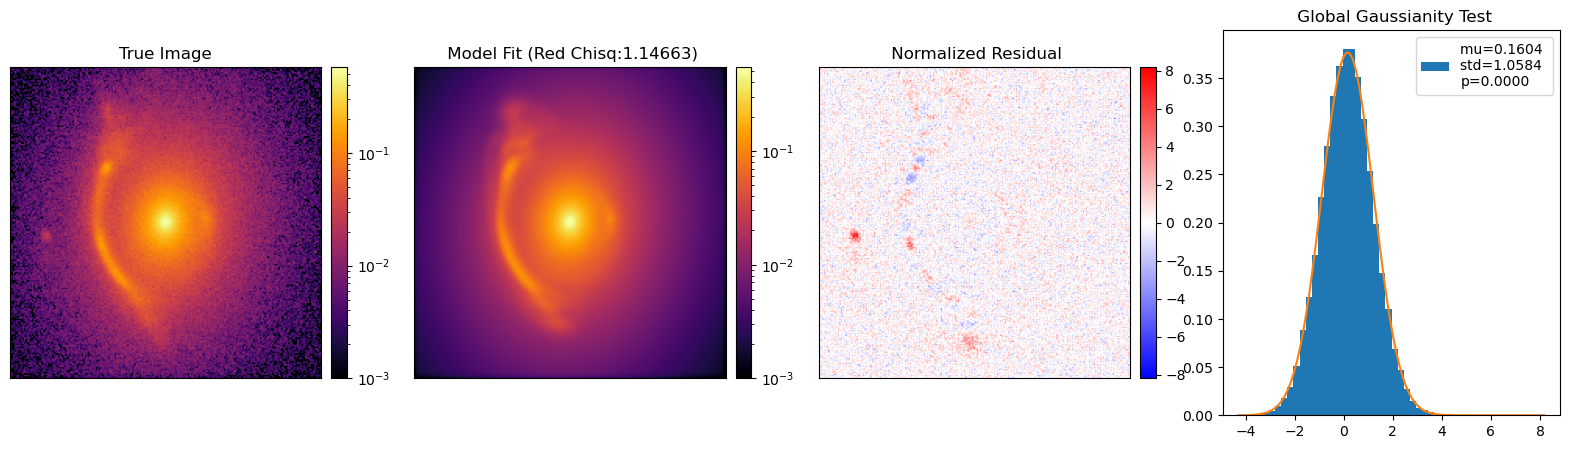

In [20]:
orig_err_map = get_noise_image(observed_img, background_rms, exp_time)
predicted_img, coeffs = lens_sim.lstsq_simulate(med_x, observed_img, prob_model.err_map)
coeffs_fwd = coeffs/ lens_sim.conversion_factor


sersic_coeff = coeffs_fwd[0]
shapelets_coeffs = coeffs_fwd[1:]
amp_names = shapelets.Shapelets(n_max)._amp_names

if len(amp_names) != len(shapelets_coeffs):
    raise ValueError("Messed up keeping track of coefficients")

sersic_with_coeff = med_x[1][0] | {"Ie":sersic_coeff}

amp_dict = dict(zip(amp_names, shapelets_coeffs))
shapelets_with_coeffs = med_x[2][0] | amp_dict
med_x_fwd = [med_x[0], [sersic_with_coeff], [shapelets_with_coeffs]]
med_x_fwd = jax.tree.map(lambda x : x[jnp.newaxis], med_x_fwd) 

phys_model_fwd = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim_fwd = LensSimulator(phys_model_fwd, sim_config, bs=1)

fig, axs = plt.subplots(1,4)
fig.set_size_inches(20,5)
plot_image_results(fig, axs, jnp.array(observed_img), prefix="", lens_sim=lens_sim_fwd, predicted_params=med_x_fwd, background_rms = background_rms, exp_time = exp_time, use_backward=False)
plt.show()

In [140]:
from typing import NamedTuple
from alternate_inference.mclmc_alt import isokinetic_mclachlan_smart

run_key = jax.random.key(1)
lens_sim_test = LensSimulator(
    model_seq.phys_model,
    model_seq.sim_config,
    bs=1,
)

def log_prob(z):
    return model_seq.prob_model.log_prob(lens_sim_test, z)[0]

kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=log_prob,
    integrator=isokinetic_mclachlan_smart,
    inverse_mass_matrix=inverse_mass_matrix,
)

init_pos = blackjax.mcmc.mclmc.init(jnp.median(mclmc_samples, axis=(0,1)), log_prob, run_key)

class MCLMCParams(NamedTuple):
    """Additional information on the MCLMC transition."""
    L: float
    step_size: float
    inverse_mass_matrix:float

# @jax.jit
def quick_chain_no_adapt(start_state, params, num_smp):
    @jax.jit
    def step(previous_state, rng_key):
        state, info = kernel(params.inverse_mass_matrix)(
            rng_key=rng_key,
            state=previous_state,
            L=params.L,
            step_size=params.step_size,
        )
        return state, info
    start_key = jax.random.key(0)
    keys = jax.random.split(start_key, num_smp)

    energy_errors = []

    state = start_state
    for i in range(num_smp):
        state, info = step(state, keys[i])
        energy_errors.append(info.energy_change)

    return energy_errors
        
# errs = quick_chain_no_adapt(init_pos, params_test, 50)
dim = init_pos.position.shape[-1]


In [141]:
step_sizes = jnp.logspace(-4, 2, 10)
variances = []
for eps in step_sizes:
    params_test = MCLMCParams(L=10.0, step_size=eps, inverse_mass_matrix=debug_hist.inverse_mass_matrix[0, -1])
    errs = quick_chain_no_adapt(init_pos, params_test, 50)
    variances.append((1/len(errs)) * jnp.sum(jnp.square(jnp.array(errs))/dim))

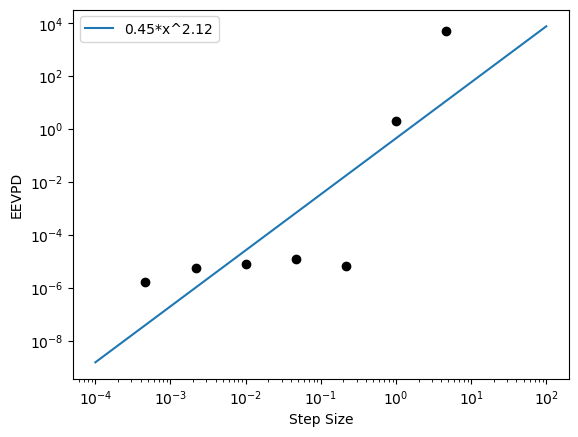

In [145]:
from scipy.optimize import curve_fit
f = lambda x, a, b : a *x +b

finite = jnp.isfinite(jnp.log(jnp.array(variances)))
popt, pcov = curve_fit(f, jnp.log(step_sizes[finite]), jnp.log(jnp.array(variances)[finite]))

plt.scatter(step_sizes, variances, color="black")
plt.plot(step_sizes, jnp.exp(f(jnp.log(step_sizes), *popt)), label=f"{jnp.exp(popt[1]):.2f}*x^{popt[0]:.2f}")
plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.ylim(bottom=
plt.xlabel("Step Size")
plt.ylabel("EEVPD")
plt.show()

In [146]:
dim=mclmc_samples.shape[-1]
samples = mclmc_samples[:, :,:].reshape(-1, dim)
mean = jnp.mean(samples, axis=0)
inv_cov =  jnp.linalg.inv(jnp.cov(samples.T))
qz_true =tfd.MultivariateNormalFullCovariance(loc=mean, covariance_matrix=jnp.cov(samples.T))

In [147]:
direction = jnp.squeeze(qz_true.sample(1, run_key) - mean)
# magnitude = jnp.mean(samples, axis=0)
# direction /= jnp.linalg.norm(direction)

In [148]:
jnp.sqrt(direction.T @ inv_cov@ direction)

Array(3.390096, dtype=float32)

In [149]:

lens_sim_test_2 = LensSimulator(
    model_seq.phys_model,
    model_seq.sim_config,
    bs=1,
)
@jax.jit
def log_prob(z):
    return model_seq.prob_model.log_prob(lens_sim_test_2, z)[0]


lp_and_grad = jax.jit(jax.vmap(jax.value_and_grad(log_prob)))
mean_log_prob, mean_grad = lp_and_grad(mean[None,:])

In [150]:
num_path=20
steps = jnp.logspace(-6, 2, num_path)

lps = []
grads = []
sigmas = []
for i in range(10):
    direction = jnp.squeeze(qz_true.sample(1, jax.random.key(i)) - mean)
    path = mean + steps[:, None]*direction
    lp, grd = lp_and_grad(path)
    lps.append(lp)
    grads.append(grd)
    sigmas.append(steps * jnp.sqrt(direction.T @ inv_cov@ direction))

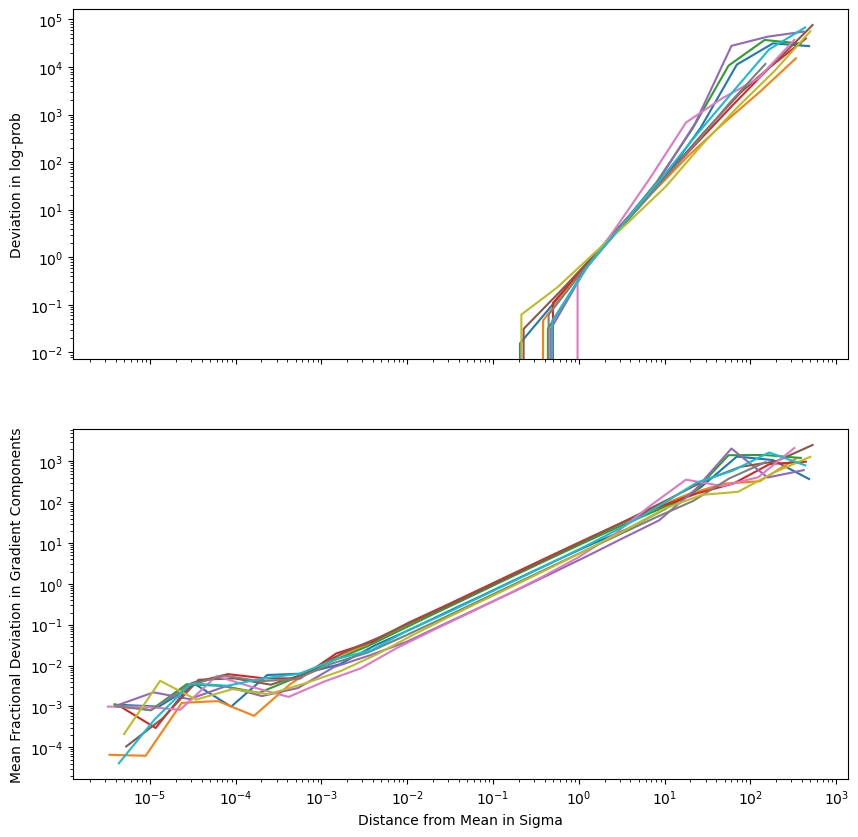

In [151]:
# lp = log_prob(path)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.set_size_inches(10, 10)
for i in range(10):
    lp_diff = mean_log_prob - lps[i]

    
    fractional_grad_diff = jnp.mean(jnp.abs((grads[i]-mean_grad)/mean_grad), axis=-1)
    ax1.plot(sigmas[i], lp_diff)
    ax2.plot(sigmas[i], fractional_grad_diff)
    # ax3.plot(steps, jnp.linalg.norm(grads[i]-mean_grad, axis=-1))
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')
# ax3.set_yscale('log')
ax1.set_ylabel('Deviation in log-prob')
ax2.set_ylabel('Mean Fractional Deviation in Gradient Components')
ax2.set_xlabel('Distance from Mean in Sigma')
plt.show()